<a href="https://colab.research.google.com/github/devinoctavian/titanic-dataframe/blob/main/df_titanic_102022430024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",Laki-Laki,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.duplicated().sum()

np.int64(4)

In [3]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [4]:
df.Sex.value_counts()

,count
Sex,
male,576
female,312
Perempuan,2
Laki-Laki,1


In [5]:
df['Sex'] = df['Sex'].replace({'Laki-Laki' : 'male', 'Perempuan' : 'female'})
df.Sex.value_counts()

,count
Sex,
male,577
female,314


In [6]:
df.Embarked.value_counts()

,count
Embarked,
S,641
C,168
Q,77
Southampton,3


In [7]:
df['Embarked'] = df['Embarked'].replace({'Southampton' : 'S'})
df.Embarked.value_counts()

,count
Embarked,
S,644
C,168
Q,77


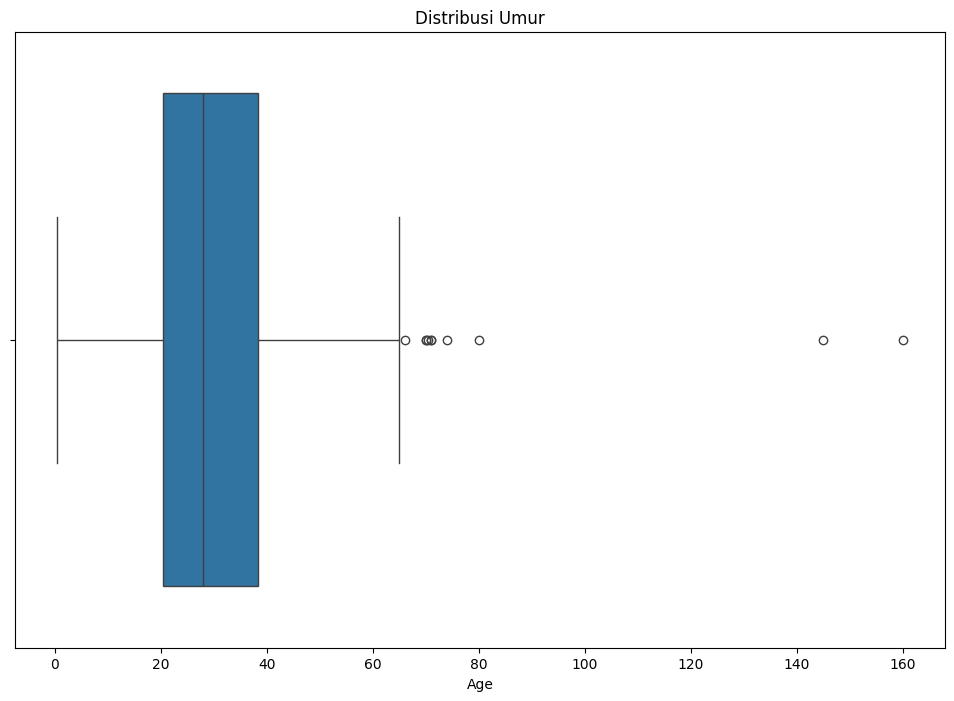

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.boxplot(x=df['Age'])
plt.title('Distribusi Umur')
plt.show()

In [10]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

IQR: 17.875
Lower Bound: -6.4375
Upper Bound: 65.0625


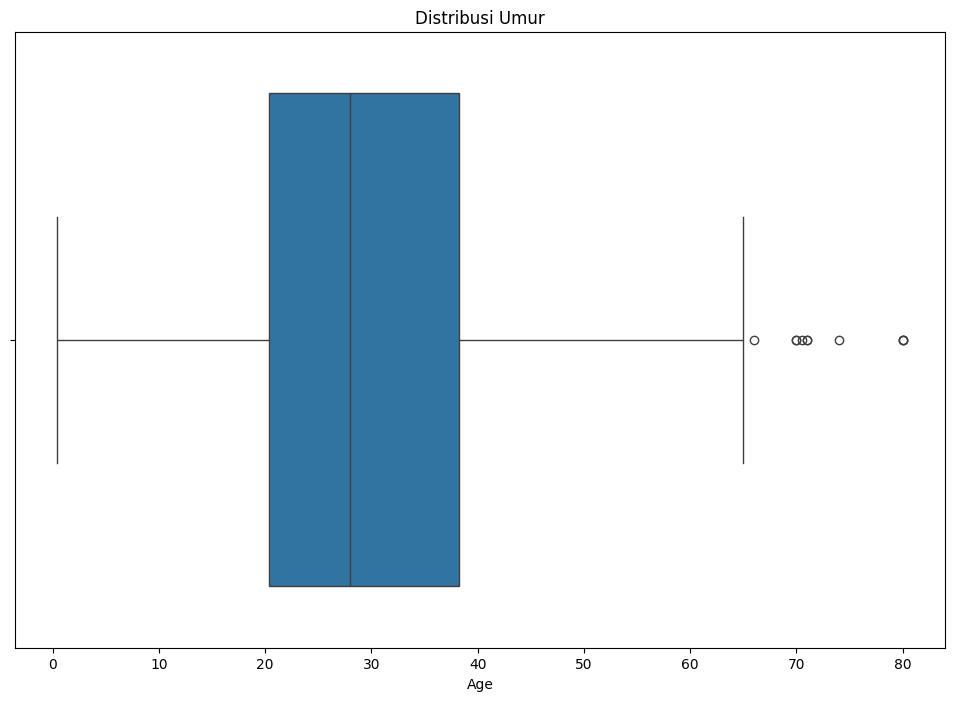

In [11]:
df.loc[df['Age'] > 80, 'Age'] = 80 # Penumpang Lansia

plt.figure(figsize=(12, 8))
sns.boxplot(x=df['Age'])
plt.title('Distribusi Umur')
plt.show()

In [13]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,175
SibSp,0
Parch,0
Ticket,0
Fare,0


In [15]:
df.dropna(subset=['Embarked'], inplace=True)
df.fillna(value={'Age': df['Age'].mean()}, inplace=True)

del_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df.drop(columns=del_cols, inplace=True, errors='ignore')

df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [16]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [17]:
df['Sex'] = df['Sex'].map({'male' : 0, 'female' : 1})
df['Embarked'] = df['Embarked'].map({'S' : 0, 'C' : 1, 'Q' : 2})
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0
